# Lab: Data Visualization and Visual Thinking

The U.S. Bureau of Transportation Statistics collects information about scheduled domestic flights. In this lab, you will use the ideas from **Data Visualization and Visual Thinking** to examine a documented sample of 5,000 completed, non-diverted flights from May 2026.


## Learning goals

By the end of this lab, you should be able to:

- load and inspect a CSV file as a Pandas DataFrame;
- distinguish Pandas data types from quantitative and categorical feature types;
- check for missing values;
- create and label a histogram and a bar chart;
- describe a distribution by its typical values, range, and skew;
- use `.describe()` to check estimates made from a histogram;
- explain how histogram bins and axis scales affect a figure; and
- identify conclusions that can and cannot be supported by a sample; and
- find a documented dataset, audit every feature, and interpret its quantitative and categorical distributions.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You are still responsible for understanding every part of your submission and checking suggestions against your notebook's output. At the end of the lab, disclose whether you used an AI tool and how you evaluated its advice.


## Dataset

The [U.S. Bureau of Transportation Statistics (BTS) Reporting Carrier On-Time Performance data](https://www.transtats.bts.gov/DL_SelectFields.aspx?QO_fu146_anzr=b0-gvzr&gnoyr_VQ=FGJ) contains 611,735 reported domestic flight records for May 2026. Completed, non-diverted flights with recorded values for all five selected features were eligible for this lab. Canceled flights, diverted flights, and records missing any selected feature were excluded before the sample was drawn.

The dataset is a reproducible random sample of 5,000 eligible flights. Each observation represents one completed, non-diverted domestic flight in that sample. Because incomplete records were removed before sampling, finding no missing values in the dataset does not mean that the original BTS data had no missing values. Conclusions from this sample describe the eligible flights and should not automatically be generalized to canceled or diverted flights.

| Feature | Description |
| --- | --- |
| `airline` | Airline that reported the flight |
| `origin_city` | Departure city |
| `destination_city` | Arrival city |
| `distance_miles` | Nonstop flight distance in miles |
| `arrival_delay_minutes` | Minutes between scheduled and actual arrival; negative values mean the flight arrived early |


## Load and preview the data

Import Pandas using the conventional alias `pd`. Read `data/bts_flights_may_2026_sample.csv` into a DataFrame named `flights`.


In [11]:
# Write your code here.
import pandas as pd
flights = pd.read_csv("data/bts_flights_may_2026_sample.csv")


Display the first five rows of the DataFrame.


In [12]:
# Write your code here.
flights.head()

,airline,origin_city,destination_city,distance_miles,arrival_delay_minutes
0,Alaska Airlines,"Anchorage, AK","Chicago, IL",2846,65
1,Alaska Airlines,"Anchorage, AK","Cordova, AK",160,-1
2,Alaska Airlines,"Anchorage, AK","Fairbanks, AK",261,-18
3,Alaska Airlines,"Anchorage, AK","Juneau, AK",571,-21
4,Alaska Airlines,"Anchorage, AK","Juneau, AK",571,-14


Display the last five rows of the DataFrame.


In [13]:
# Write your code here.
flights.tail()


,airline,origin_city,destination_city,distance_miles,arrival_delay_minutes
4995,United Airlines,"West Palm Beach/Palm Beach, FL","Chicago, IL",1144,0
4996,United Airlines,"West Palm Beach/Palm Beach, FL","Houston, TX",956,-22
4997,United Airlines,"West Palm Beach/Palm Beach, FL","Houston, TX",956,-29
4998,United Airlines,"West Palm Beach/Palm Beach, FL","Newark, NJ",1024,-26
4999,United Airlines,"West Palm Beach/Palm Beach, FL","Newark, NJ",1024,7


## Inspect the DataFrame

Display a summary of the DataFrame that includes the feature names, the number of non-missing values, and the Pandas data types.


In [14]:
# Write your code here.
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   airline                5000 non-null   object
 1   origin_city            5000 non-null   object
 2   destination_city       5000 non-null   object
 3   distance_miles         5000 non-null   int64 
 4   arrival_delay_minutes  5000 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 195.4+ KB


**How many observations are in the DataFrame?**

Your answer:
5000

Count the missing values in every feature.


In [15]:
# Write your code here.
flights.isna().sum()

airline                  0
origin_city              0
destination_city         0
distance_miles           0
arrival_delay_minutes    0
dtype: int64

## Classify the features

A **quantitative feature** records an amount or measurement for which arithmetic is meaningful. A **categorical feature** assigns observations to groups or labels.


**Complete the table with the Pandas data type, feature type, and number of missing values for each feature. Use `.info()` and `.isnull().sum()`; enter 0 when no values are missing.**

| Feature | Pandas data type | Feature type | Number of missing values |
| --- | --- | --- | ---: |
| `airline` | object | categorical | 0 |
| `origin_city` | object | categorical | 0 |
| `destination_city` | object | categorical | 0 |
| `distance_miles` | int64 | quantitative | 0 |
| `arrival_delay_minutes` | int64 | quantitative | 0 |



## Which destination city is most common in the sample?

Calculate and display the frequency of each destination city. Save the result as `destination_counts`.


In [16]:
# Write your code here.
destination_counts = flights["destination_city"].value_counts()
destination_counts


destination_city
Chicago, IL                       296
Atlanta, GA                       222
Dallas/Fort Worth, TX             210
Denver, CO                        209
Washington, DC                    165
                                 ... 
Gunnison, CO                        1
Allentown/Bethlehem/Easton, PA      1
Idaho Falls, ID                     1
Jamestown, ND                       1
Yuma, AZ                            1
Name: count, Length: 238, dtype: int64

Import `matplotlib.pyplot` using the conventional alias `plt`. Use `.head(10)` on `destination_counts` to select the ten most frequent destination cities, then create a bar chart. Give the figure a descriptive title and label both axes.


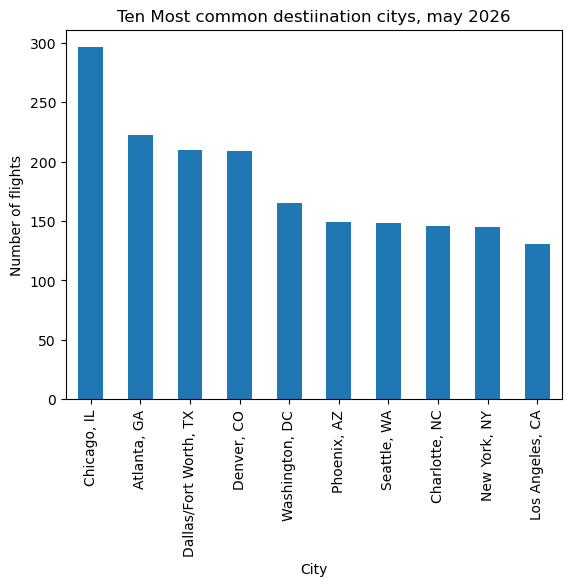

In [17]:
# Write your code here.
import matplotlib.pyplot as plt

destination_counts.head(10).plot(kind = "bar")
plt.title("Ten Most common destiination citys, may 2026")
plt.xlabel("City")
plt.ylabel("Number of flights")
plt.show()

**Which destination city is most common in the sample?**

Your answer:
chicago, IL

## What was the distribution of arrival delays?

Negative values represent early arrivals, zero represents an on-time arrival, and positive values represent late arrivals.

Create a histogram of `arrival_delay_minutes` using the default number of bins. Give the figure a descriptive title and label both axes.


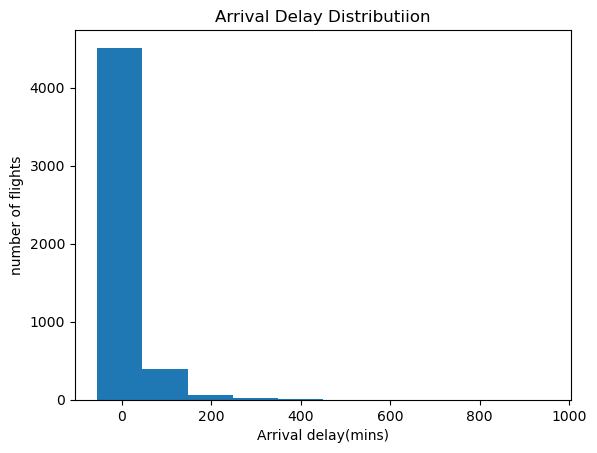

In [18]:
# Write your code here.
flights["arrival_delay_minutes"].plot(kind = "hist")
plt.title("Arrival Delay Distributiion")
plt.xlabel("Arrival delay(mins)")
plt.ylabel("number of flights")
plt.show()

**Approximately what arrival-delay value appears most common?**

Your answer: 0


**What is the approximate range from the smallest to the largest arrival-delay value?**

Your answer:-50 to 1000


**Does the arrival-delay distribution appear symmetric or skewed?**

Your answer:skewd


Display a numerical summary of `arrival_delay_minutes`.


In [19]:
# Write your code here.
flights["arrival_delay_minutes"].describe()

count    5000.000000
mean        6.098800
std        48.335493
min       -55.000000
25%       -16.000000
50%        -6.000000
75%        10.000000
max       953.000000
Name: arrival_delay_minutes, dtype: float64

Calculate and display the exact mode of `arrival_delay_minutes` using `.mode()`.


In [20]:
# Write your code here.
flights["arrival_delay_minutes"].mode()

0   -8
Name: arrival_delay_minutes, dtype: int64

**How closely did the calculated mode match the most common value you estimated from the histogram?**

Your answer: -8 relative to the 100 minuite bar width isnt far off from 0.


**How closely did the minimum and maximum from `.describe()` match the range you estimated from the histogram?**

Your answer:fairly close min estamated at -50 actual min -55 max estamate 1000 actual max 953


**Is the mean greater than, less than, or approximately equal to the median?**

Your answer: they are about the same mean is slightly larger than median


**How is the relationship between the mean and median connected to the histogram's shape?**

Your answer: The histogram has a long tail to the right, with a few flights delayed hundreds of minutes, up to 953. The mean uses every value, so those few extreme flights pull it up. The median is just the middle flight, so the extremes don't move it.

## Applying the principles: histogram bins

Re-create the arrival-delay histogram using exactly 5 bins.


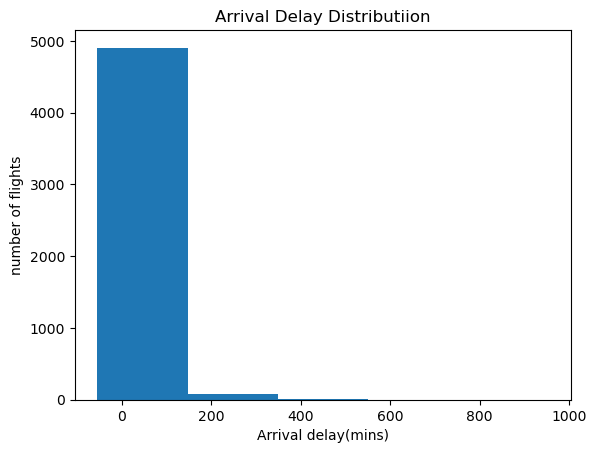

In [21]:
# Write your code here.
flights["arrival_delay_minutes"].plot(kind = "hist", bins =5)
plt.title("Arrival Delay Distributiion")
plt.xlabel("Arrival delay(mins)")
plt.ylabel("number of flights")
plt.show()

Re-create the arrival-delay histogram using exactly 25 bins.


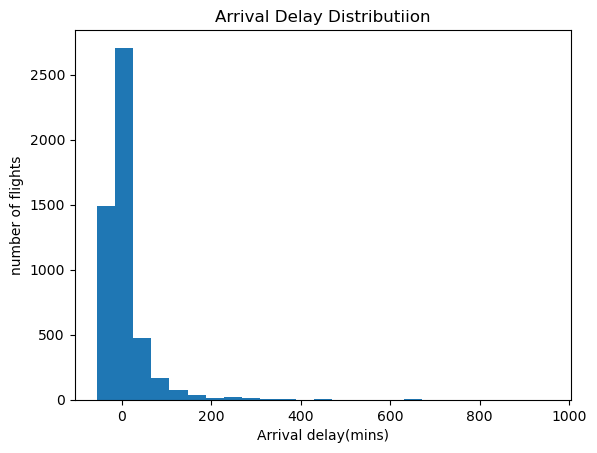

In [22]:
# Write your code here.
flights["arrival_delay_minutes"].plot(kind = "hist", bins= 25)
plt.title("Arrival Delay Distributiion")
plt.xlabel("Arrival delay(mins)")
plt.ylabel("number of flights")
plt.show()

**What changed when the number of bins was reduced to 5?**

Your answer:
the bars got thicker

**What changed when the number of bins was increased to 25?**

Your answer: a new bar apeared benigth 0 and a aditionall data point is scene at just over 600 mins


**Which bin setting communicates the distribution most clearly?**

Your answer: surely 25


## Applying the principles: a misleading vertical axis

Run both cells below and compare the figures.


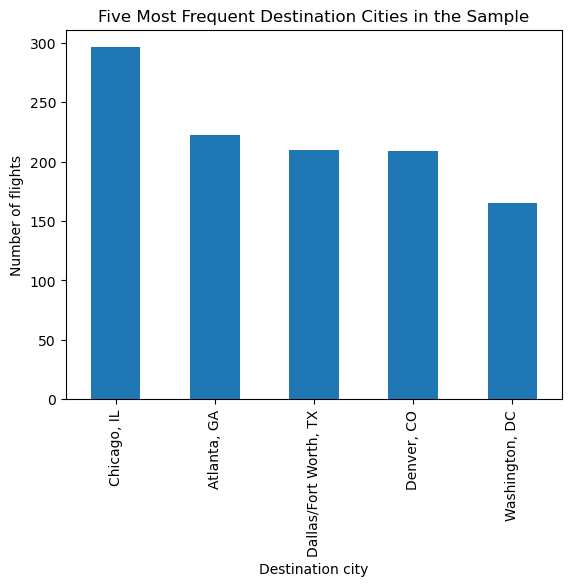

In [23]:
top_destinations = destination_counts.head(5)
top_destinations.plot(kind="bar")
plt.title("Five Most Frequent Destination Cities in the Sample")
plt.xlabel("Destination city")
plt.ylabel("Number of flights")
plt.show()


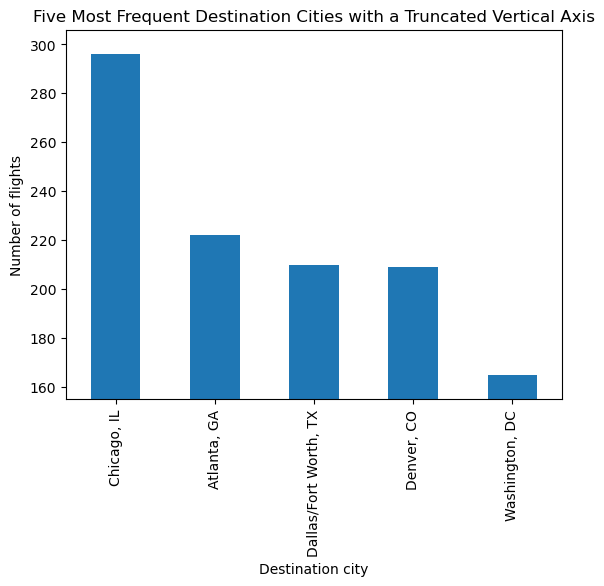

In [24]:
top_destinations.plot(kind="bar")
plt.ylim(top_destinations.min() - 10, top_destinations.max() + 10)
plt.title("Five Most Frequent Destination Cities with a Truncated Vertical Axis")
plt.xlabel("Destination city")
plt.ylabel("Number of flights")
plt.show()


**How does the truncated axis change the apparent differences among the destination cities?**

Your answer: the truncated axis shows a more visually aparent difference in the relative height of each bar


**Which chart communicates the counts more honestly?**

Your answer: in this case probably the truncated version, as the representation is more aparent. all the results are over 150 theres not much need to vvisually represent lower than that, your just loosing details. 


## Is this sample representative?

Review the dataset description at the top of the lab before answering these questions.


**What time period is represented by the source data?**

Your answer: One month. May 2026.


**Which flights were eligible to be included in the sample?**

Your answer: valid non diverted or canceled flights, with no na results. 


**Which flights and records were excluded before the sample was selected?**

Your answer: canceled flights, diverted flights, and missing feature records. 


**Does finding no missing values in the sample prove that the original BTS data had no missing values?**

Your answer:No not nessasarilly. It just means the sample does not contain any missing values. However we have the advantage of knowing from the initial description that the missing values were excluded from the sample regardless, well documented in this case. 


**Why should conclusions from this sample not automatically be generalized to canceled or diverted flights?**

Your answer: The data is liikely unfiarly representative of the real results because canceled or diverted flights are not conntained in the data set. Its likely that the real results are considerably worse than presented in terms of "ontime mean" 


## Choosing a chart

Choose a histogram, bar chart, or pie chart for each question. Use the question and number of categories to justify your choice.


**Which chart would you use to show the frequency of each airline?**

Your answer: bar chart would be Ideal, becuase the data represented is categorical by airline. A pie chart would have to many categorys to be represetative as there are over 10 airlines(a pizza is only 8 slices and thats alot).  

**Which chart would you use to show what proportion of sampled flights were early, on time, and delayed? Use arrival delays below 0, equal to 0, and above 0 minutes, respectively.**

Your answer: For sure a Pie chart would be Ideal for this. There are only three categorys availible perfect for a pie chart addiitionally they are expected to be proportions. What else do we use pie for but serving portions. 


**Which chart would you use to show the distribution of flight distances?**

Your answer: This set you would use a histogram. Histograms are better sutied to a distrobution where bar and pie charts have categorys. A histogram is quantitative.


## Explore a dataset of your own

Apply the same inspection and visualization process to a different dataset that interests you.

### 1. Find and describe your dataset

Start with [Kaggle Datasets](https://www.kaggle.com/datasets), the [UCI Machine Learning Repository](https://archive.ics.uci.edu/), or [Data.gov](https://catalog.data.gov/). You can also search a city or state open-data portal. Search for a topic you enjoy, such as sports, music, animals, transportation, or the environment.

Choose a manageable CSV file with a data dictionary (or equivalent feature documentation), at least one quantitative feature, and at least one categorical feature with a manageable number of categories. Use a different dataset from the flights and penguins already used in class. Save the file in this notebook's `data` folder.

Read the data dictionary before choosing your features. In a short paragraph, describe the dataset's subject, what one row represents, and its time period and geographic coverage if documented. Include its title, publisher or creator, a direct link to the dataset, and a link to the data dictionary. State when information is not documented instead of guessing.


**Dataset description and source links:**

Your answer:


### 2. Load the data and describe every feature

Load your CSV into a new DataFrame with a descriptive name ending in `_df`, such as `movies_df`, `weather_df`, or `animals_df`. Choose a name that describes your dataset and use it consistently throughout your analysis. Display its first five rows, shape, `.info()`, and `.isnull().sum()` to inspect its features, storage types, and missing values. Use a relative path so your notebook can run on another computer.


In [25]:
# Load and inspect your chosen dataset here.
import pandas as pd
caffeine_df = pd.read_csv("data/caffeine.csv")
display(caffeine_df.head())
display(caffeine_df.shape)
caffeine_df.info()
caffeine_df.isnull().sum()

,drink,Volume (ml),Calories,Caffeine (mg),type
0,Costa Coffee,256.993715,0,277,Coffee
1,Coffee Friend Brewed Coffee,250.191810,0,145,Coffee
2,Hell Energy Coffee,250.191810,150,100,Coffee
3,Killer Coffee (AU),250.191810,0,430,Coffee
4,Nescafe Gold,250.191810,0,66,Coffee


(610, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   drink          610 non-null    object 
 1   Volume (ml)    610 non-null    float64
 2   Calories       610 non-null    int64  
 3   Caffeine (mg)  610 non-null    int64  
 4   type           610 non-null    object 
dtypes: float64(1), int64(2), object(2)
memory usage: 24.0+ KB


drink            0
Volume (ml)      0
Calories         0
Caffeine (mg)    0
type             0
dtype: int64

Complete the table below with **one row for every feature** in your dataset. Add as many rows as needed. Use the data dictionary to summarize what each feature means, including units or category-code meanings where relevant.

- **Data type:** quantitative or categorical; identify identifiers and date/time features explicitly when appropriate. A numeric identifier is not a quantitative measurement.
- **Data storage type:** the actual Pandas dtype shown by `.info()` or `.dtypes`, such as `int64`, `float64`, `object`, `str`, or `datetime64[ns]`.
- **Missing values:** the number reported for that feature, including 0 when there are none. Count missing values before removing records. If the dictionary defines special missing codes, such as -999 or "Unknown", explain how you handle those codes and make sure the counts reflect that decision.


| Feature | Description from the data dictionary (including units/codes) | Data type | Data storage type | Number of missing values |
| --- | --- | --- | --- | ---: |
| `drink` | Name | Identifier | object | 0 |
| `Volume (ml)` | serving volume in milliliters | quantitative | float64 | 0 | 
| `Calories` | calories per serving; 0 is for ground coffee and tea becuase the user adds sugar or cream etc | quantitative | int64 | 0 |
| `Caffeine (mg)` | caffeine per serving in milligrams | quantitative | int64 | 0 |
| `type` | Drink category | categorical | object | 0 |


**Missing-value codes or other data preparation, if applicable:**

Your answer: wont be charting calories. 


### 3. Visualize one quantitative feature

Choose one quantitative measurement and create an appropriate visualization of its distribution, such as a histogram. Include a descriptive title, a horizontal-axis label naming the feature and its units, and a vertical-axis label explaining what the heights represent. Explain any excluded missing values or other filtering. Do not use an ID number as your quantitative feature.


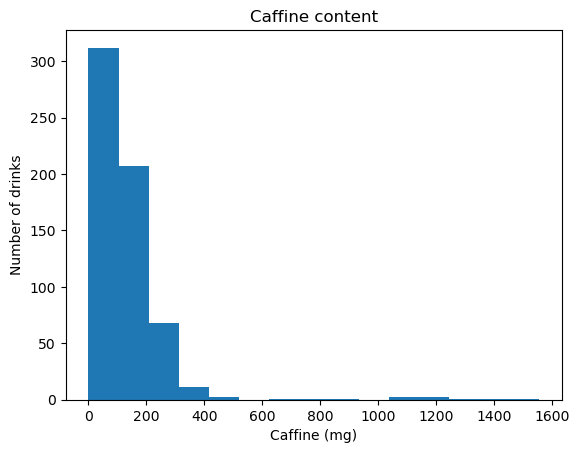

In [28]:
# Create and label your quantitative-feature visualization here.
caffeine_df["Caffeine (mg)"].plot(kind = "hist", bins = 15)
plt.title("Caffine content")
plt.xlabel("Caffine (mg)")
plt.ylabel("Number of drinks")
plt.show()

**Which feature did you choose, and why is this chart appropriate?**

Your answer: I picked caffine content in milligrams, the histogram plot is apropriate because it shows the distrobution of caffine content by number of drinks. I picked 15 bins instead of 10 for a better shape representation with the tail well over 1000mg

**In at least one complete sentence, describe what the figure tells you about this feature.** Refer to a visible pattern such as typical values, range, shape, or unusual observations, using values and units where possible. Describe the observations in your dataset without assuming they represent a larger population.

Your interpretation:  Most caffeinated products in this dataset contain less than ~300 mg of caffeine (the large majority of the 610 drinks), while a few drinks push past 1,000 mg per serving, giving the distribution a strong right skew.

### 4. Visualize one categorical feature

Choose a categorical feature and create an appropriate visualization of its distribution. A bar chart of category counts is a good choice; use `.value_counts()` to obtain numeric bar heights from text labels. Include a descriptive title and labels identifying the categories and counts or percentages on the axes. If you choose a pie chart for a small number of categories, label the slices and their shares instead of axes. Explain any excluded missing values or categories, and identify the denominator if you use percentages.


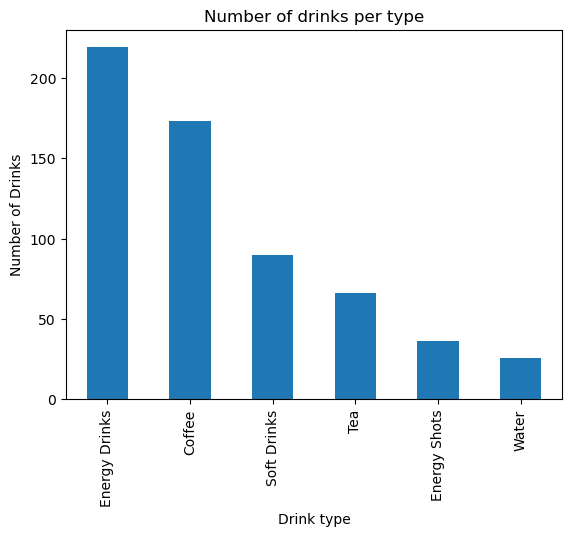

In [34]:
# Create and label your categorical-feature visualization here.
caffeine_count = caffeine_df["type"].value_counts()
caffeine_count.plot(kind = "bar")
plt.title("Number of drinks per type")
plt.xlabel("Drink type")
plt.ylabel("Number of Drinks")
plt.show()

**Which feature did you choose, and why is this chart appropriate?**

Your answer: I chose number of drinks per drink type. a bar chart is Ideal for categorical data with many categorys a pie chart actually might also be applicable in this senario if you wanted to see the proportion of drinks per drink types

**In at least one complete sentence, describe what the figure tells you about this feature.** Identify a meaningful pattern, such as the most or least common category or a difference in counts or shares. Support the interpretation with evidence visible in your figure.

Your interpretation: This bar graph shows us that a majority of marketed caffinated drinks are energy drinks, and actually beats even coffee in terms of drinks availible. 


## Reflect on AI assistance

Complete one of the following statements.

**If you used an AI tool:**

- Tool used:
- What I asked it to help with:
- One suggestion I checked against my code, chart, or output:
- What I accepted, modified, or rejected—and why:

**If you did not use an AI tool:**

- I did not use an AI tool for this assignment.
- One resource or troubleshooting strategy I used instead was:


Your response: Yes I used claude for this. Claude helped with pands syntax and concepts, matplotlib syntax, and some debugging. verification of concepts, and proof reading. One thing that was originally modifyed due to ai was the -50 estamate which I had orginally as zero this was also later further verifyed by the .describe() function which resulted in -55 so the ai's estamate was infact  the correct one. 


## Submission checklist

- All code cells run from top to bottom without errors.
- The destination-city bar chart has a descriptive title and labeled axes.
- The default, 5-bin, and 25-bin arrival-delay histograms are included and labeled.
- Both vertical-axis demonstrations are included.
- Every question has one response in its own answer cell.
- The sample questions are answered using the dataset documentation.
- The chosen dataset and its data dictionary are linked and described.
- The feature table includes a description, data type, storage type, and missing-value count for every feature.
- One quantitative and one categorical feature have appropriate labeled visualizations and at least one sentence of interpretation each.
- The chosen CSV is included in the `data` folder with the submitted notebook, and relative paths work.
- The AI-use reflection is complete and honest.
